
--- Dataset ---
   age        bmi  blood_pressure  cholesterol  steps_per_day  medical_cost  \
0   58  19.031722             163          188           9319   5213.176711   
1   71  23.910795             147          286           6941   5470.318627   
2   48  18.488064              86          248           8644   4144.462885   
3   34  28.959634             133          226           5855   6787.085698   
4   62  28.476635              80          264           7547   5583.565089   

   disease  
0        1  
1        1  
2        1  
3        0  
4        1  

Missing Before:
 age                0
bmi               21
blood_pressure     0
cholesterol        0
steps_per_day      0
medical_cost       0
disease            0
dtype: int64
Missing After:
 age               0
bmi               0
blood_pressure    0
cholesterol       0
steps_per_day     0
medical_cost      0
disease           0
dtype: int64


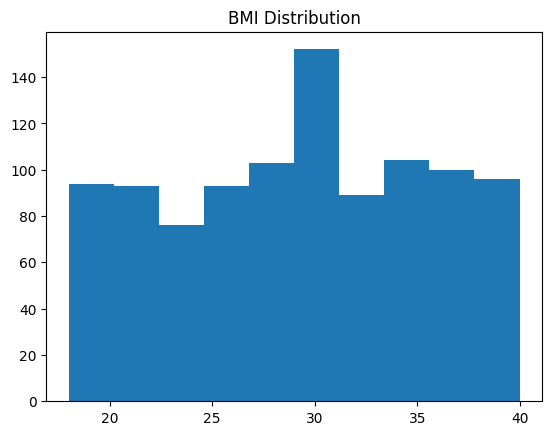


--- Correlation ---
                      age       bmi  blood_pressure  cholesterol  \
age             1.000000  0.015565        0.095955    -0.050475   
bmi             0.015565  1.000000       -0.024474    -0.005582   
blood_pressure  0.095955 -0.024474        1.000000    -0.000598   
cholesterol    -0.050475 -0.005582       -0.000598     1.000000   
steps_per_day  -0.050274 -0.037224       -0.006496    -0.018008   
medical_cost    0.017118  0.909851        0.012270     0.045761   
disease         0.027985  0.401132        0.298863     0.357238   

                steps_per_day  medical_cost   disease  
age                 -0.050274      0.017118  0.027985  
bmi                 -0.037224      0.909851  0.401132  
blood_pressure      -0.006496      0.012270  0.298863  
cholesterol         -0.018008      0.045761  0.357238  
steps_per_day        1.000000     -0.179244 -0.018903  
medical_cost        -0.179244      1.000000  0.407821  
disease             -0.018903      0.407821  1.00

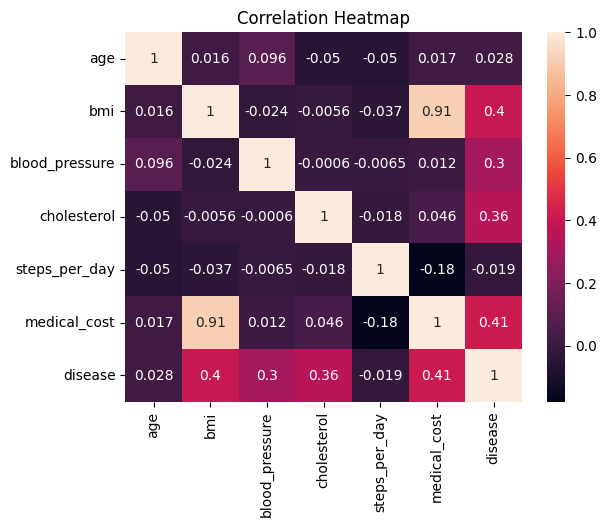


--- Linear Regression ---
Coefficient: [201.8806798]
Intercept: 142.4967152953268


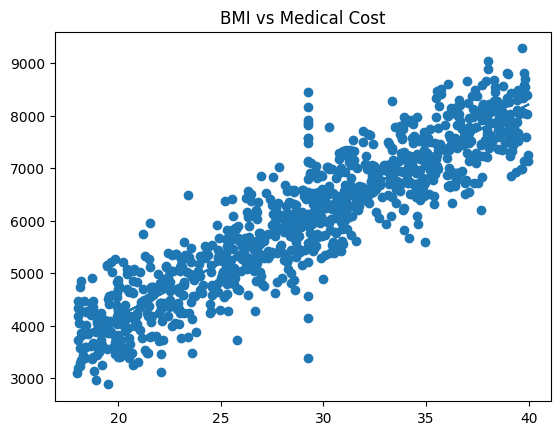


--- Logistic Regression ---
Accuracy: 0.9

Confusion Matrix:
 [[ 33  12]
 [ 13 192]]


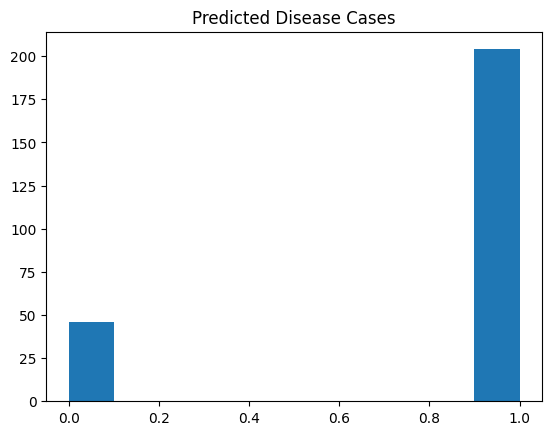


--- Avg Cost by Age ---
age
20    6121.688575
21    5817.809696
22    6362.498307
23    5949.594519
24    6591.650676
Name: medical_cost, dtype: float64


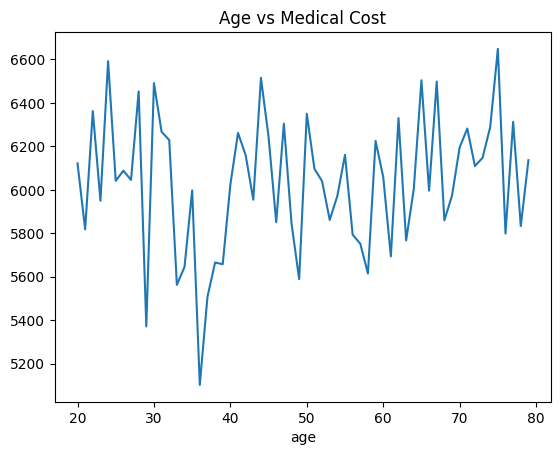


--- Pivot Table ---
 disease            0            1
age                              
20       5214.444405  6217.187962
21       4121.657693  6029.828696
22       5214.577782  6608.481276
23       3646.119865  6410.289449
24       5100.773436  7017.615602


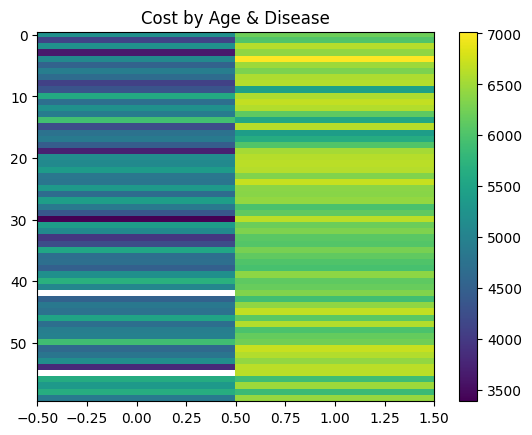


--- Simulation ---
Current Avg Cost: 6046.420198571954
After More Steps: 5895.813269847672


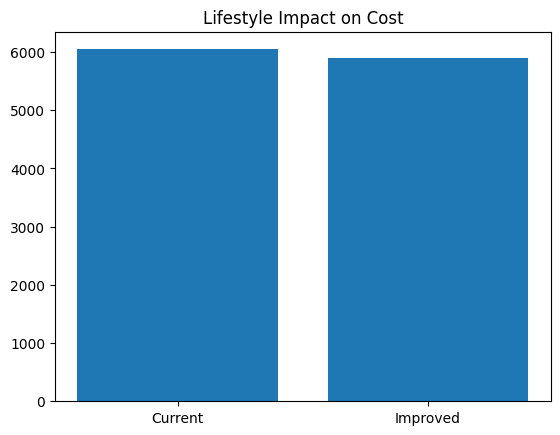


--- Insights ---
1. Higher BMI increases medical cost
2. Disease risk rises with BP & cholesterol
3. More daily steps reduce healthcare cost


In [1]:
# ===============================
# Healthcare Analytics Project
# ===============================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# -------------------------------
# 1. Generate Dataset
# -------------------------------
np.random.seed(42)
n = 1000

data = pd.DataFrame({
    'age': np.random.randint(20, 80, n),
    'bmi': np.random.uniform(18, 40, n),
    'blood_pressure': np.random.randint(80, 180, n),
    'cholesterol': np.random.randint(150, 300, n),
    'steps_per_day': np.random.randint(1000, 15000, n)
})

# Medical cost (regression target)
data['medical_cost'] = (
    200 * data['bmi'] +
    1.5 * data['cholesterol'] +
    2 * data['blood_pressure'] -
    0.05 * data['steps_per_day'] +
    np.random.normal(0, 500, n)
)

# Disease risk (classification target)
data['disease'] = (
    (data['bmi'] > 30) |
    (data['cholesterol'] > 240) |
    (data['blood_pressure'] > 140)
).astype(int)

print("\n--- Dataset ---")
print(data.head())

# -------------------------------
# 2. Data Cleaning
# -------------------------------
data.loc[0:20, 'bmi'] = np.nan

print("\nMissing Before:\n", data.isnull().sum())

data['bmi'] = data['bmi'].fillna(data['bmi'].mean())

print("Missing After:\n", data.isnull().sum())

plt.figure()
plt.hist(data['bmi'])
plt.title("BMI Distribution")
plt.show()

# -------------------------------
# 3. Correlation Analysis
# -------------------------------
corr = data.corr()

print("\n--- Correlation ---\n", corr)

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

# -------------------------------
# 4. Linear Regression (Medical Cost)
# -------------------------------
X_lr = data[['bmi']]
y_lr = data['medical_cost']

lr = LinearRegression()
lr.fit(X_lr, y_lr)

print("\n--- Linear Regression ---")
print("Coefficient:", lr.coef_)
print("Intercept:", lr.intercept_)

plt.figure()
plt.scatter(X_lr, y_lr)
plt.plot(X_lr, lr.predict(X_lr))
plt.title("BMI vs Medical Cost")
plt.show()

# -------------------------------
# 5. Logistic Regression (Disease Prediction)
# -------------------------------
X = data[['age', 'bmi', 'blood_pressure', 'cholesterol']]
y = data['disease']

X_train, X_test, y_train, y_test = train_test_split(X, y)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\n--- Logistic Regression ---")
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

plt.figure()
plt.hist(y_pred)
plt.title("Predicted Disease Cases")
plt.show()

# -------------------------------
# 6. Group Analysis
# -------------------------------
grouped = data.groupby('age')['medical_cost'].mean()

print("\n--- Avg Cost by Age ---")
print(grouped.head())

plt.figure()
grouped.plot()
plt.title("Age vs Medical Cost")
plt.show()

# -------------------------------
# 7. Pivot Table Analysis
# -------------------------------
pivot = pd.pivot_table(
    data,
    values='medical_cost',
    index='age',
    columns='disease',
    aggfunc='mean'
)

print("\n--- Pivot Table ---\n", pivot.head())

plt.figure()
plt.imshow(pivot, aspect='auto')
plt.colorbar()
plt.title("Cost by Age & Disease")
plt.show()

# -------------------------------
# 8. Simulation (Lifestyle Improvement)
# -------------------------------
def simulate_steps(increase):
    temp = data.copy()
    temp['steps_per_day'] += increase

    temp['medical_cost'] = (
        200 * temp['bmi'] +
        1.5 * temp['cholesterol'] +
        2 * temp['blood_pressure'] -
        0.05 * temp['steps_per_day']
    )

    return temp['medical_cost'].mean()

base = data['medical_cost'].mean()
new = simulate_steps(3000)

print("\n--- Simulation ---")
print("Current Avg Cost:", base)
print("After More Steps:", new)

plt.figure()
plt.bar(['Current', 'Improved'], [base, new])
plt.title("Lifestyle Impact on Cost")
plt.show()

# -------------------------------
# 9. Final Insights
# -------------------------------
print("\n--- Insights ---")
print("1. Higher BMI increases medical cost")
print("2. Disease risk rises with BP & cholesterol")
print("3. More daily steps reduce healthcare cost")